# RQ2 Notebook 07 — Mechanism Analyses

Five findings in the RQ2 write-up were derived during analysis but had no notebook behind
them. This notebook makes them reproducible.

| Finding | Section | Claim |
|---|---|---|
| **2** | A | Exposure concentrates at library level, not vulnerability level |
| **5** | B | Upstream window length is the strongest determinant of timely mitigation |
| **6** | C | Residual lateness is chronic and size-independent |
| **7** | D | Most mitigation is incidental maintenance, and incidental is slower |
| **11** | E | Transparency works by routing mitigation out of the incidental channel |

Section F covers smaller supporting numbers cited in the text.

**Inputs:** `rq2_master_pairwise.csv` (1,677 pairs) and `rq2_blast_radius_per_cve.csv`
(832 CVEs), both from notebooks 02 and 03.
**Produces:** `T11`–`T16`, `F10`, `F11`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency

pd.set_option('display.width', 230)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(20260811)

OUT = Path('../../data/rq2')

master = pd.read_csv(OUT / 'rq2_master_pairwise.csv')
blast  = pd.read_csv(OUT / 'rq2_blast_radius_per_cve.csv')
for c in ['adoption_date', 'report_date', 'fix_date', 'release_date', 'disclosure_date']:
    master[c] = pd.to_datetime(master[c], errors='coerce')

# Exposure stage. Defined from the two facts that matter, not from event order:
#   was the fixed release out?            delay_release >= 0
#   was the vulnerability still private?  delay_disclosure < 0
# Ordering the checks this way is correct for every pattern, including those where
# disclosure precedes release (S2, S3, T2, T3, T5). Asking "which upstream event was
# most recent" would wrongly label those as safe.
LADDER = ['Before release', 'Safe window', 'After disclosure']

def exposure_stage(row):
    if row.delay_disclosure >= 0:
        return 'After disclosure'
    if row.delay_release >= 0:
        return 'Safe window'
    return 'Before release'

master['stage'] = master.apply(exposure_stage, axis=1)
master['late'] = (master.stage == 'After disclosure').astype(int)
master['safe'] = (master.stage == 'Safe window').astype(int)
master['window'] = (master.disclosure_date - master.release_date).dt.total_seconds() / 86400
master['bulk'] = (master.commit_n_CVEs > 1).astype(int)

print(f'pairs {len(master):,} | CVEs {master.CVE.nunique()} | repos {master.downstream_repo.nunique()}')
print(f'late {100 * master.late.mean():.1f}% | safe window {100 * master.safe.mean():.1f}%')

pairs 1,677 | CVEs 191 | repos 742
late 85.3% | safe window 13.2%


---
## A — Exposure concentrates at library level *(Finding 2)*

**Claim.** Downstream projects are not exposed to scattered independent vulnerabilities.
They are exposed repeatedly through a small set of libraries that generate CVE after CVE.

Exposure is aggregated from the CVE to the upstream artifact (`G:A`, version stripped), and
concentration is measured at that level.

In [2]:
artifact = (
    blast.groupby('upstream_GA')
    .agg(CVEs=('CVE_ID', 'size'), dependents=('dependents', 'sum'))
    .sort_values('dependents', ascending=False)
)
artifact['% of all exposure'] = (100 * artifact.dependents / artifact.dependents.sum()).round(2)
artifact['cumulative %'] = artifact['% of all exposure'].cumsum().round(1)

summary_A = pd.DataFrame([{
    'Distinct upstream artifacts': len(artifact),
    'Top 10 share of exposure %': round(artifact['% of all exposure'].head(10).sum(), 1),
    'Top 25 share %': round(artifact['% of all exposure'].head(25).sum(), 1),
    'Artifacts with >1 CVE': int((artifact.CVEs > 1).sum()),
    '% of artifacts with >1 CVE': round(100 * (artifact.CVEs > 1).mean(), 1),
    'Max CVEs on one artifact': int(artifact.CVEs.max()),
    'Median CVEs per artifact': int(artifact.CVEs.median()),
}])
display(summary_A)

T11 = artifact.head(15).reset_index()
display(T11)

# Repeat-CVE artifacts carry disproportionate exposure.
rep = artifact[artifact.CVEs > 1]
print(f'Artifacts with repeat CVEs: {len(rep)} of {len(artifact)} ({100 * len(rep) / len(artifact):.0f}%)')
print(f'  they carry {100 * rep.dependents.sum() / artifact.dependents.sum():.1f}% of all exposure')
print(f'  and account for {int(rep.CVEs.sum())} of {int(artifact.CVEs.sum())} CVEs')

,Distinct upstream artifacts,Top 10 share of exposure %,Top 25 share %,Artifacts with >1 CVE,% of artifacts with >1 CVE,Max CVEs on one artifact,Median CVEs per artifact
0,376,58.9,76.2,130,34.6,35,1


,upstream_GA,CVEs,dependents,% of all exposure,cumulative %
0,commons-io:commons-io,1,4386,9.87,9.9
1,com.fasterxml.jackson.core:jackson-databind,6,4137,9.31,19.2
2,junit:junit,1,4015,9.03,28.2
3,com.thoughtworks.xstream:xstream,22,3706,8.34,36.6
4,com.google.guava:guava,1,3247,7.30,43.8
5,org.apache.logging.log4j:log4j-core,5,2225,5.01,48.9
6,org.bouncycastle:bcprov-jdk15on,12,1660,3.73,52.6
7,com.h2database:h2,3,1048,2.36,54.9
8,org.apache.httpcomponents:httpclient,5,905,2.04,57.0
9,commons-fileupload:commons-fileupload,4,860,1.93,58.9


Artifacts with repeat CVEs: 130 of 376 (35%)
  they carry 61.1% of all exposure
  and account for 586 of 832 CVEs


---
## B — Upstream window length determines timely mitigation *(Finding 5)*

**Claim.** The safe window is not a fixed period; its length is the upstream project's choice
of when to disclose relative to release. That length predicts whether downstream mitigates in
time better than any downstream property.

The window is `disclosure_date - release_date` at the CVE level. Pairs with a non-positive
window had no safe period at all — disclosure preceded release.

In [3]:
no_window = master[master.window <= 0]
w = master[master.window > 0].copy()

print(f'pairs with a positive window : {len(w):,} ({100 * len(w) / len(master):.0f}%)')
print(f'pairs with NO window at all  : {len(no_window):,} ({100 * len(no_window) / len(master):.0f}%)')
print(f'  of those, {100 * no_window.late.mean():.1f}% mitigated after disclosure')

BANDS = [(0, 7, 'Under 7 days'), (7, 30, '7-30 days'),
         (30, 90, '30-90 days'), (90, np.inf, 'Over 90 days')]

rows = []
for lo, hi, lab in BANDS:
    s = w[(w.window >= lo) & (w.window < hi)]
    if len(s) == 0:
        continue
    rows.append({'Upstream window': lab, 'Pairs': len(s), 'CVEs': s.CVE.nunique(),
                 'Mitigated in safe window %': round(100 * s.safe.mean(), 1),
                 'Mitigated after disclosure %': round(100 * s.late.mean(), 1),
                 'Median delay from release (d)': round(s.delay_release.median(), 1)})
T12 = pd.DataFrame(rows)
display(T12)

rho, p = spearmanr(w.window, w.safe)
print(f'Spearman(window length, mitigated in time): rho = {rho:.3f}, p = {p:.2e}')

# Logistic fit with a cluster bootstrap over downstream repositories.
from sklearn.linear_model import LogisticRegression

X = np.log1p(w.window.to_numpy()).reshape(-1, 1)
y = w.safe.to_numpy()

def fit(X, y):
    return LogisticRegression(max_iter=2000, C=1e6).fit(X, y).coef_[0][0]

point = fit(X, y)
repos = w.downstream_repo.to_numpy()
uniq = np.unique(repos)
idx = {r: np.where(repos == r)[0] for r in uniq}
draws = []
for _ in range(1000):
    picked = rng.choice(uniq, len(uniq), replace=True)
    rr = np.concatenate([idx[r] for r in picked])
    if y[rr].min() == y[rr].max():
        continue
    draws.append(fit(X[rr], y[rr]))
lo_, hi_ = np.percentile(draws, [2.5, 97.5])

display(pd.DataFrame([{
    'Predictor': 'log(upstream window days)',
    'Odds ratio': round(np.exp(point), 3),
    'CI low': round(np.exp(lo_), 3), 'CI high': round(np.exp(hi_), 3),
    'Significant': 'yes' if (np.exp(lo_) > 1 or np.exp(hi_) < 1) else 'no',
    'n pairs': len(w), 'n repo clusters': len(uniq),
}]))

short, longw = w[w.window < 7], w[(w.window >= 30) & (w.window < 90)]
print(f'\nSafe-window mitigation: {100 * short.safe.mean():.1f}% when the window is under a week,')
print(f'{100 * longw.safe.mean():.1f}% when it is 30-90 days '
      f'({longw.safe.mean() / short.safe.mean():.1f}x).')

pairs with a positive window : 1,533 (91%)
pairs with NO window at all  : 144 (9%)
  of those, 95.1% mitigated after disclosure


,Upstream window,Pairs,CVEs,Mitigated in safe window %,Mitigated after disclosure %,Median delay from release (d)
0,Under 7 days,654,52,6.0,93.3,31.7
1,7-30 days,316,46,13.0,85.1,74.5
2,30-90 days,247,29,29.1,68.4,104.2
3,Over 90 days,316,43,22.2,77.5,500.7


Spearman(window length, mitigated in time): rho = 0.215, p = 1.89e-17


,Predictor,Odds ratio,CI low,CI high,Significant,n pairs,n repo clusters
0,log(upstream window days),1.331,1.209,1.481,yes,1533,707



Safe-window mitigation: 6.0% when the window is under a week,
29.1% when it is 30-90 days (4.9x).


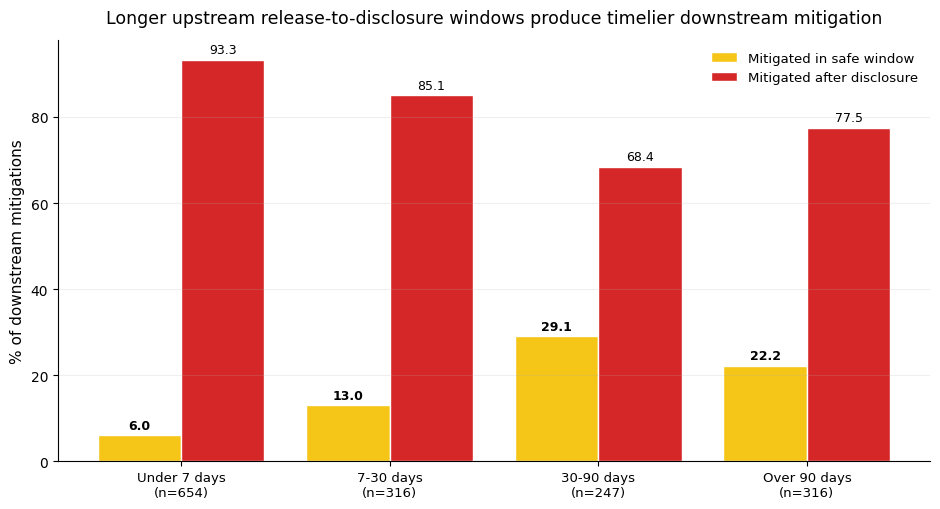

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
labels = T12['Upstream window'].tolist()
x = np.arange(len(labels))
ax.bar(x - 0.2, T12['Mitigated in safe window %'], 0.4, label='Mitigated in safe window',
       color='#f5c518', edgecolor='white')
ax.bar(x + 0.2, T12['Mitigated after disclosure %'], 0.4, label='Mitigated after disclosure',
       color='#d62728', edgecolor='white')
for i, r in T12.iterrows():
    ax.text(i - 0.2, r['Mitigated in safe window %'] + 1.5, f"{r['Mitigated in safe window %']:.1f}",
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i + 0.2, r['Mitigated after disclosure %'] + 1.5, f"{r['Mitigated after disclosure %']:.1f}",
            ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(labels, T12.Pairs)], fontsize=9.5)
ax.set_ylabel('% of downstream mitigations', fontsize=11)
ax.set_title('Longer upstream release-to-disclosure windows produce timelier downstream mitigation',
             fontsize=12.5, pad=12)
ax.legend(frameon=False, fontsize=9.5)
ax.grid(axis='y', alpha=0.2)
for s_ in ['top', 'right']:
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F10_window_length_vs_timeliness.png', dpi=200, bbox_inches='tight')
plt.show()

---
## C — Lateness is chronic and size-independent *(Finding 6)*

**Claim.** Once upstream timing is accounted for, the remaining lateness concentrates in a
stable population of projects that are late every time. Project size does not distinguish
them.

Restricted to repositories with at least three exposures, so a per-repository rate is
meaningful.

In [5]:
MIN_EXPOSURES = 3

repo_rate = master.groupby('downstream_repo').agg(pairs=('late', 'size'), late_rate=('late', 'mean'))
repo_rate = repo_rate[repo_rate.pairs >= MIN_EXPOSURES]
cve_rate = master.groupby('CVE').agg(pairs=('late', 'size'), late_rate=('late', 'mean'))
cve_rate = cve_rate[cve_rate.pairs >= MIN_EXPOSURES]

T13 = pd.DataFrame([
    {'Level': 'Downstream repository', 'Units': len(repo_rate),
     'Always late %': round(100 * (repo_rate.late_rate == 1).mean(), 1),
     'Always on time %': round(100 * (repo_rate.late_rate == 0).mean(), 1),
     'Mean late rate': round(repo_rate.late_rate.mean(), 3),
     'Variance of late rate': round(repo_rate.late_rate.var(), 4)},
    {'Level': 'CVE', 'Units': len(cve_rate),
     'Always late %': round(100 * (cve_rate.late_rate == 1).mean(), 1),
     'Always on time %': round(100 * (cve_rate.late_rate == 0).mean(), 1),
     'Mean late rate': round(cve_rate.late_rate.mean(), 3),
     'Variance of late rate': round(cve_rate.late_rate.var(), 4)},
])
display(T13)

print(f'Among {len(repo_rate)} repositories with >= {MIN_EXPOSURES} exposures, '
      f'{int((repo_rate.late_rate == 1).sum())} were late on every one and '
      f'{int((repo_rate.late_rate == 0).sum())} on time on every one.')
print()

# Does project size explain it?
size_rows = []
for col, lab in [('downstream_loc', 'Lines of code'),
                 ('downstream_class_num', 'Class count'),
                 ('dependents', 'Upstream dependents')]:
    v = master[col]
    ok = v.notna()
    rho, p = spearmanr(v[ok], master.delay_disclosure[ok])
    hi = v > v.median()
    size_rows.append({'Predictor': lab,
                      'Spearman rho vs delay': round(rho, 3), 'p': round(p, 4),
                      'Late % above median': round(100 * master.loc[hi, 'late'].mean(), 1),
                      'Late % below median': round(100 * master.loc[~hi & ok, 'late'].mean(), 1),
                      'Predictive': 'yes' if p < 0.05 else 'no'})
display(pd.DataFrame(size_rows))

# Repeat exposure: does a repository improve with experience?
rc = master.groupby('downstream_repo').CVE.nunique()
master['n_cves_repo'] = master.downstream_repo.map(rc)
exp_rows = []
for lo, hi_, lab in [(1, 1, '1 CVE'), (2, 4, '2-4 CVEs'), (5, 99, '5+ CVEs')]:
    s = master[(master.n_cves_repo >= lo) & (master.n_cves_repo <= hi_)]
    exp_rows.append({'Repository exposure count': lab, 'Repos': s.downstream_repo.nunique(),
                     'Pairs': len(s), 'Late %': round(100 * s.late.mean(), 1),
                     'Safe window %': round(100 * s.safe.mean(), 1),
                     'Median delay from disclosure (d)': round(s.delay_disclosure.median(), 1)})
display(pd.DataFrame(exp_rows))
print('More-exposed repositories are not more timely, so experience alone does not help.')

,Level,Units,Always late %,Always on time %,Mean late rate,Variance of late rate
0,Downstream repository,167,64.7,2.4,0.850,0.0633
1,CVE,145,45.5,1.4,0.842,0.0483


Among 167 repositories with >= 3 exposures, 108 were late on every one and 4 on time on every one.



,Predictor,Spearman rho vs delay,p,Late % above median,Late % below median,Predictive
0,Lines of code,-0.022,0.3667,87.5,83.0,no
1,Class count,-0.018,0.4641,87.8,82.9,no
2,Upstream dependents,0.002,0.9370,91.5,79.0,no


,Repository exposure count,Repos,Pairs,Late %,Safe window %,Median delay from disclosure (d)
0,1 CVE,438,438,82.9,15.5,68.9
1,2-4 CVEs,236,595,85.2,12.6,84.6
2,5+ CVEs,68,644,87.0,12.3,31.6


More-exposed repositories are not more timely, so experience alone does not help.


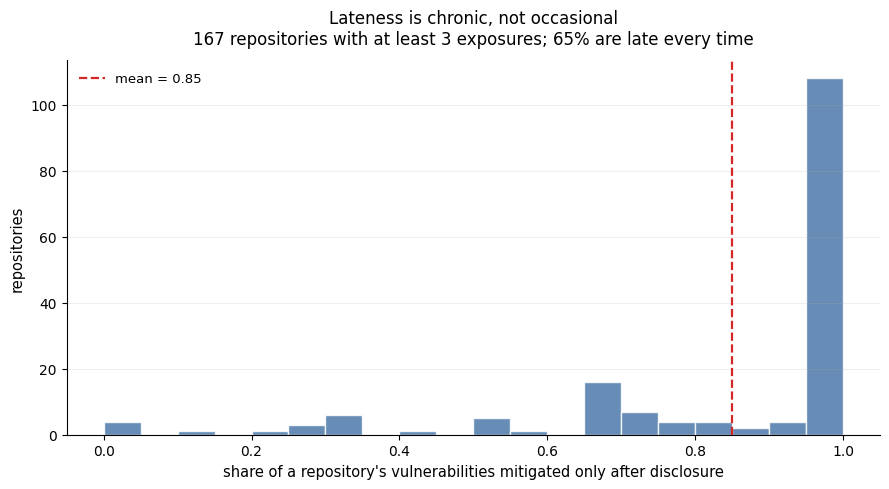

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(repo_rate.late_rate, bins=np.linspace(0, 1, 21), color='#4c78a8',
        edgecolor='white', alpha=0.85)
ax.axvline(repo_rate.late_rate.mean(), color='#d62728', ls='--', lw=1.6,
           label=f'mean = {repo_rate.late_rate.mean():.2f}')
ax.set_xlabel('share of a repository\'s vulnerabilities mitigated only after disclosure', fontsize=10.5)
ax.set_ylabel('repositories', fontsize=10.5)
ax.set_title(f'Lateness is chronic, not occasional\n'
             f'{len(repo_rate)} repositories with at least {MIN_EXPOSURES} exposures; '
             f'{100 * (repo_rate.late_rate == 1).mean():.0f}% are late every time',
             fontsize=12, pad=12)
ax.legend(frameon=False, fontsize=9.5)
ax.grid(axis='y', alpha=0.2)
for s_ in ['top', 'right']:
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F11_chronic_lateness.png', dpi=200, bbox_inches='tight')
plt.show()

---
## D — Most mitigation is incidental, and incidental is slower *(Finding 7)*

**Claim.** A large share of mitigations arrive through commits resolving several
vulnerabilities at once — routine dependency bumps that incidentally clear a CVE rather than
responses to it. That channel is measurably slower.

`commit_n_CVEs` counts distinct CVEs resolved by the same commit URL, computed in notebook 02.

In [7]:
rows = []
for b, lab in [(0, 'Single-CVE commit (targeted)'), (1, 'Multi-CVE commit (bulk)')]:
    s = master[master.bulk == b]
    rows.append({'Mitigation type': lab, 'Pairs': len(s), '% of pairs': round(100 * len(s) / len(master), 1),
                 'After disclosure %': round(100 * s.late.mean(), 1),
                 'Safe window %': round(100 * s.safe.mean(), 1),
                 'Median delay from disclosure (d)': round(s.delay_disclosure.median(), 1),
                 'Median delay from release (d)': round(s.delay_release.median(), 1)})
T14 = pd.DataFrame(rows)
display(T14)

u, p = mannwhitneyu(master.loc[master.bulk == 0, 'delay_disclosure'],
                    master.loc[master.bulk == 1, 'delay_disclosure'])
print(f'Mann-Whitney on delay_disclosure, targeted vs bulk: p = {p:.2e}')

tab = pd.crosstab(master.bulk, master.late)
chi2, p_chi, _, _ = chi2_contingency(tab.values)
print(f'Chi-square on P(after disclosure): chi2 = {chi2:.2f}, p = {p_chi:.2e}')
print(f'Commits resolving more than one CVE: {master.commit_url[master.bulk == 1].nunique()} '
      f'of {master.commit_url.nunique()}; max CVEs on one commit = {int(master.commit_n_CVEs.max())}')
print()

# The batching paradox: delay falls across successive CVEs while lateness rises.
seq_df = master[master.n_cves_repo >= 3].sort_values(['downstream_repo', 'disclosure_date']).copy()
seq_df['seq'] = seq_df.groupby('downstream_repo').cumcount() + 1

seq_rows = []
for q, lab in [(1, 'First exposure'), (2, 'Second'), (3, 'Third and later')]:
    s = seq_df[seq_df.seq == q] if q < 3 else seq_df[seq_df.seq >= 3]
    seq_rows.append({'Exposure order within repository': lab, 'Pairs': len(s),
                     'Median delay from disclosure (d)': round(s.delay_disclosure.median(), 1),
                     'After disclosure %': round(100 * s.late.mean(), 1),
                     'Bulk commit %': round(100 * s.bulk.mean(), 1)})
display(pd.DataFrame(seq_rows))

rho_d, p_d = spearmanr(seq_df.seq, seq_df.delay_disclosure)
rho_l, p_l = spearmanr(seq_df.seq, seq_df.late)
print(f'Spearman(sequence, delay)   rho = {rho_d:.3f}, p = {p_d:.2e}   <- delay FALLS')
print(f'Spearman(sequence, late)    rho = {rho_l:.3f}, p = {p_l:.2e}   <- lateness RISES')
print('Both follow from batching: one bump clears a backlog, appearing fast against the')
print('newest CVE in the batch and late against every older one.')

,Mitigation type,Pairs,% of pairs,After disclosure %,Safe window %,Median delay from disclosure (d),Median delay from release (d)
0,Single-CVE commit (targeted),921,54.9,82.0,16.5,46.8,67.9
1,Multi-CVE commit (bulk),756,45.1,89.3,9.3,72.5,130.1


Mann-Whitney on delay_disclosure, targeted vs bulk: p = 1.50e-05
Chi-square on P(after disclosure): chi2 = 17.09, p = 3.57e-05
Commits resolving more than one CVE: 250 of 1171; max CVEs on one commit = 14



,Exposure order within repository,Pairs,Median delay from disclosure (d),After disclosure %,Bulk commit %
0,First exposure,167,106.0,83.2,49.1
1,Second,167,70.3,83.8,61.1
2,Third and later,631,32.3,87.6,70.2


Spearman(sequence, delay)   rho = -0.203, p = 2.16e-10   <- delay FALLS
Spearman(sequence, late)    rho = 0.131, p = 4.48e-05   <- lateness RISES
Both follow from batching: one bump clears a backlog, appearing fast against the
newest CVE in the batch and late against every older one.


---
## E — Transparency routes mitigation out of the incidental channel *(Finding 11)*

**Claim.** Transparency's effect on the disclosure deadline (notebook 06) operates through
the channel identified in Section D: silent fixes are disproportionately cleared as a side
effect of maintenance, transparent fixes prompt targeted response.

In [8]:
rows = []
for c in ['Silent', 'Transparent']:
    s = master[master['class'] == c]
    rows.append({'Class': c, 'Pairs': len(s),
                 'Bulk (incidental) %': round(100 * s.bulk.mean(), 1),
                 'Single-CVE (targeted) %': round(100 * (1 - s.bulk.mean()), 1),
                 'Median CVEs per commit': int(s.commit_n_CVEs.median()),
                 'After disclosure %': round(100 * s.late.mean(), 1),
                 'Safe window %': round(100 * s.safe.mean(), 1)})
T15 = pd.DataFrame(rows)
display(T15)

tab = pd.crosstab(master['class'], master.bulk)
chi2, p, _, _ = chi2_contingency(tab.values)
print(f'Chi-square, class vs mitigation channel: chi2 = {chi2:.2f}, p = {p:.2e}')

# Same contrast restricted to the within-repository sample, which controls for the project.
wr = pd.read_csv(OUT / 'rq2_within_repo_sample.csv')
wr['bulk'] = (wr.commit_n_CVEs > 1).astype(int)
display(
    wr.groupby('class').agg(Pairs=('bulk', 'size'),
                            **{'Bulk %': ('bulk', lambda s: round(100 * s.mean(), 1))})
)
print('The channel difference persists within the same repositories, so it is a property of')
print('the upstream reporting behaviour rather than of which projects were exposed.')

,Class,Pairs,Bulk (incidental) %,Single-CVE (targeted) %,Median CVEs per commit,After disclosure %,Safe window %
0,Silent,1100,51.0,49.0,2,89.3,10.1
1,Transparent,577,33.8,66.2,1,77.6,19.2


Chi-square, class vs mitigation channel: chi2 = 44.56, p = 2.47e-11


,Pairs,Bulk %
class,,
Silent,492,63.2
Transparent,250,51.2


The channel difference persists within the same repositories, so it is a property of
the upstream reporting behaviour rather than of which projects were exposed.


---
## F — Supporting numbers cited in the write-up

In [9]:
same_day = master[(master.delay_release >= 0) & (master.delay_release < 1)]
fix_stage = master[master.stage == 'Before release']

rows = [
    {'Quantity': 'Adopted same day as upstream release', 'Pairs': len(same_day),
     '% of all pairs': round(100 * len(same_day) / len(master), 2),
     'Note': f"silent {100 * len(same_day[same_day['class'] == 'Silent']) / (master['class'] == 'Silent').sum():.2f}%, "
             f"transparent {100 * len(same_day[same_day['class'] == 'Transparent']) / (master['class'] == 'Transparent').sum():.2f}%"},
    {'Quantity': 'Adopted after fix but before release (source builders)', 'Pairs': len(fix_stage),
     '% of all pairs': round(100 * len(fix_stage) / len(master), 2),
     'Note': f'median {fix_stage.delay_fix.median():.1f} days after the fix commit'},
    {'Quantity': 'Adopted before the release tag existed', 'Pairs': int((master.delay_release < 0).sum()),
     '% of all pairs': round(100 * (master.delay_release < 0).mean(), 2),
     'Note': 'projects tracking source or snapshots'},
    {'Quantity': 'Median avoidable exposure per late pair', 'Pairs': int(master.late.sum()),
     '% of all pairs': round(100 * master.late.mean(), 2),
     'Note': f'{master.loc[master.late == 1, "delay_disclosure"].median():.0f} days after disclosure'},
]
T16 = pd.DataFrame(rows)
display(T16)

# Tail behaviour by class, full sample (the within-repo version is in notebook 06).
tail = []
for c in ['Silent', 'Transparent']:
    v = master.loc[(master['class'] == c) & (master.delay_disclosure >= 0), 'delay_disclosure']
    tail.append({'Class': c, 'Pairs exposed past disclosure': len(v),
                 'Still exposed at 30 d %': round(100 * (v > 30).mean(), 1),
                 'at 90 d %': round(100 * (v > 90).mean(), 1),
                 'at 365 d %': round(100 * (v > 365).mean(), 1)})
display(pd.DataFrame(tail))
print('In the full sample the two classes have near-identical tails. The heavier transparent')
print('tail reported in notebook 06 is specific to the within-repository subset and should')
print('not be generalised.')

,Quantity,Pairs,% of all pairs,Note
0,Adopted same day as upstream release,37,2.21,"silent 1.64%, transparent 3.29%"
1,Adopted after fix but before release (source b...,25,1.49,median 14.1 days after the fix commit
2,Adopted before the release tag existed,62,3.70,projects tracking source or snapshots
3,Median avoidable exposure per late pair,1430,85.27,88 days after disclosure


,Class,Pairs exposed past disclosure,Still exposed at 30 d %,at 90 d %,at 365 d %
0,Silent,982,69.0,50.8,21.8
1,Transparent,448,69.2,47.5,21.0


In the full sample the two classes have near-identical tails. The heavier transparent
tail reported in notebook 06 is specific to the within-repository subset and should
not be generalised.


---
## Save

In [10]:
T11.to_csv(OUT / 'T11_upstream_artifact_concentration.csv', index=False)
T12.to_csv(OUT / 'T12_window_length_vs_timeliness.csv', index=False)
T13.to_csv(OUT / 'T13_chronic_lateness.csv', index=False)
T14.to_csv(OUT / 'T14_bulk_vs_targeted.csv', index=False)
T15.to_csv(OUT / 'T15_channel_by_class.csv', index=False)
T16.to_csv(OUT / 'T16_supporting_numbers.csv', index=False)
artifact.reset_index().to_csv(OUT / 'rq2_artifact_level_exposure.csv', index=False)
repo_rate.reset_index().to_csv(OUT / 'rq2_repo_late_rates.csv', index=False)

for f in ['T11_upstream_artifact_concentration.csv', 'T12_window_length_vs_timeliness.csv',
          'T13_chronic_lateness.csv', 'T14_bulk_vs_targeted.csv', 'T15_channel_by_class.csv',
          'T16_supporting_numbers.csv', 'rq2_artifact_level_exposure.csv',
          'rq2_repo_late_rates.csv', 'F10_window_length_vs_timeliness.png',
          'F11_chronic_lateness.png']:
    print(f)

T11_upstream_artifact_concentration.csv
T12_window_length_vs_timeliness.csv
T13_chronic_lateness.csv
T14_bulk_vs_targeted.csv
T15_channel_by_class.csv
T16_supporting_numbers.csv
rq2_artifact_level_exposure.csv
rq2_repo_late_rates.csv
F10_window_length_vs_timeliness.png
F11_chronic_lateness.png
